# Reaction–diffusion in d=2 — a UV-finite loop above d=1

**Showcases:** the pipeline in **d=2** with a *convergent* loop. The quadratic nonlinearity gives a cubic MSR vertex, so the 1-loop self-energy is a genuine momentum-dependent **bubble** $\propto g^2$; the integral $\int d^2\ell\,$ behaves as $\int d^2\ell/\ell^4$ in the UV, which converges for $d<4$ (the φ⁴ upper critical dimension). So the d=2 correction is **finite — no cutoff**.

$$\partial_t\phi = D\,\nabla^2\phi - \mu\phi - g\phi^2 + \eta,\qquad x\in\mathbb{R}^2.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
THEORY = 'reaction_diffusion_2d'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  reaction-diffusion (d=2)
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=2 · boundary=infinite · initial=stationary
Fields         : phi (x∈ℝ^2)
Response fields: phit
Parameters     :
    mu = 1.0  (positive)
    D = 1.0  (positive)
    g = 0.2  (real)
    T = 1.0  (positive)
Mean-field saddle (solved by the pipeline): phistar
Governing eqn  : (Dt + mu - D*Laplacian)*phi = -g*phi^2
Suggested run  : k=2, max_ell=1

2D reaction–diffusion field with a QUADRATIC nonlinearity — the d=2
companion of ``reaction_diffusion_quadratic_1d``.  Its 1-loop self-energy
is a genuine momentum-dependent **bubble** (not a constant mass shift),
and the loop ``∫ d²ℓ`` is closed-form in any dimension via the analytic
Symanzik momentum reduction.

    ∂_t φ = D ∇²φ − μ φ − g φ²  + η,
    ⟨η(x,t) η(x',t')⟩ = 2T δ²(x−x') δ(t−t').

MSR–JD action (response field φ̃):

    S = φ̃ (∂_

"────────────────────────────────────────────────────────────────────────\n  reaction-diffusion (d=2)\n────────────────────────────────────────────────────────────────────────\nDomain         : spatial PDE · d=2 · boundary=infinite · initial=stationary\nFields         : phi (x∈ℝ^2)\nResponse fields: phit\nParameters     :\n    mu = 1.0  (positive)\n    D = 1.0  (positive)\n    g = 0.2  (real)\n    T = 1.0  (positive)\nMean-field saddle (solved by the pipeline): phistar\nGoverning eqn  : (Dt + mu - D*Laplacian)*phi = -g*phi^2\nSuggested run  : k=2, max_ell=1\n\n2D reaction–diffusion field with a QUADRATIC nonlinearity — the d=2\ncompanion of ``reaction_diffusion_quadratic_1d``.  Its 1-loop self-energy\nis a genuine momentum-dependent **bubble** (not a constant mass shift),\nand the loop ``∫ d²ℓ`` is closed-form in any dimension via the analytic\nSymanzik momentum reduction.\n\n    ∂_t φ = D ∇²φ − μ φ − g φ²  + η,\n    ⟨η(x,t) η(x',t')⟩ = 2T δ²(x−x') δ(t−t').\n\nMSR–JD action (response f

## 2. The pipeline → theoretical cumulants (tree vs 1-loop)

Two runs at the same separations: tree, and tree+1-loop. The difference `dC(r)` is the finite d=2 bubble correction.

tree C(r0) = 0.1785   1-loop C(r0) = 0.1837   dC = 0.0053
1-loop correction all finite?  True   max|dC| = 0.005265


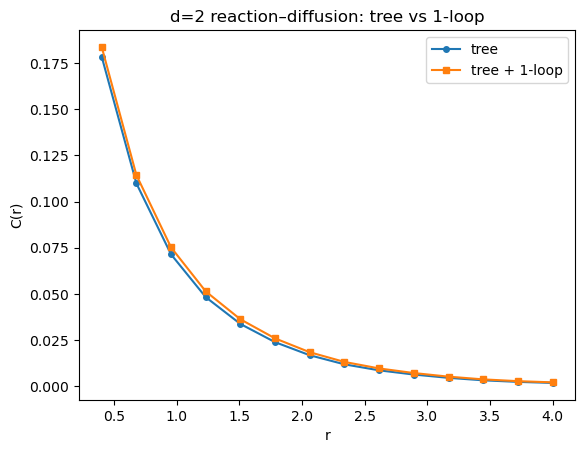

In [3]:
rs = np.linspace(0.4, 4.0, 14)        # radial separations r ≥ 0
common = dict(k=2, external_fields=[('dphi', 1), ('dphi', 1)],
              chi_grid=rs, tau_max=1.0, tau_step=1.0, 
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───   (spread to BOTH runs via **common)
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   tau_grid=(-8.0, 8.0, 33),     # explicit τ grid (array | (lo,hi,n)); overrides tau_max/step
#   spatial_points=...,           # k≥3 spatial: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)
tree = dd.run(model, dd.Config(max_ell=0, parameters={'mu': 1.0, 'D': 1.0, 'g': 0.2, 'T': 1.0}, **common), mod)
loop = dd.run(model, dd.Config(max_ell=1, parameters={'mu': 1.0, 'D': 1.0, 'g': 0.2, 'T': 1.0}, **common), mod)
mid = tree['C_tau_x'].shape[0] // 2   # τ = 0 row
C0 = np.real(tree['C_tau_x'])[mid]
C1 = np.real(loop['C_tau_x'])[mid]
dC = C1 - C0
print('tree C(r0) = %.4f   1-loop C(r0) = %.4f   dC = %.4f'
      % (C0[0], C1[0], dC[0]))
print('1-loop correction all finite? ', bool(np.all(np.isfinite(dC))),
      '  max|dC| = %.4g' % np.max(np.abs(dC)))
plt.plot(rs, C0, '-o', ms=4, label='tree')
plt.plot(rs, C1, '-s', ms=4, label='tree + 1-loop')
plt.xlabel('r'); plt.ylabel('C(r)'); plt.legend()
plt.title('d=2 reaction–diffusion: tree vs 1-loop'); plt.show()


## 3. Independent simulation

Two checks. (a) The free ($g=0$) **2-D structure factor** $S(q)$ against the tree propagator $T/(\mu+Dq^2)$. (b) The **$g^2$-scaling** of the loop: doubling $g$ quadruples `dC`, confirming a genuine $O(g^2)$ bubble (tree is $g$-independent since $\phi^*=0$).

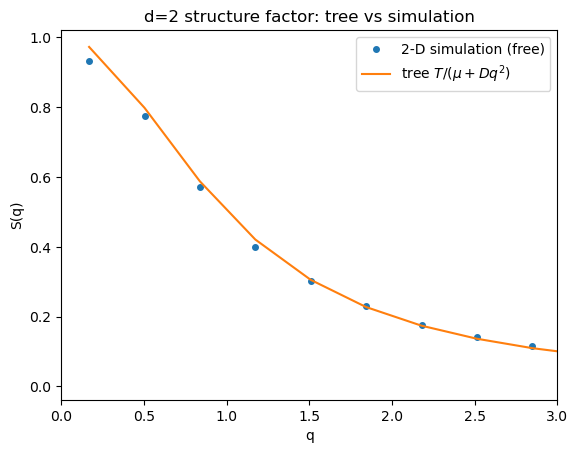

dC(2g)/dC(g) at r0 = 4.000   (O(g²) bubble → 4.0)


In [4]:
from models.spatial_field_2d_sim import simulate_2d, radial_structure_factor_2d
fp = dd.parameters_from_model(model)
snaps, meta = simulate_2d(L=20.0, N=64, mu=fp['mu'], D=fp['D'], T=fp['T'], g=0.0,
                          n_steps=50000, burn_in=10000, record_every=15, seed=3)
kc, Sq = radial_structure_factor_2d(snaps, meta, n_bins=30)
plt.plot(kc, Sq, 'o', ms=4, label='2-D simulation (free)')
plt.plot(kc, fp['T'] / (fp['mu'] + fp['D'] * kc**2), '-', label=r'tree $T/(\mu+Dq^2)$')
plt.xlim(0, 3); plt.xlabel('q'); plt.ylabel('S(q)'); plt.legend()
plt.title('d=2 structure factor: tree vs simulation'); plt.show()

# g²-scaling of the loop correction (an O(g²) bubble → ratio 4).
loop2 = dd.run(model, dd.Config(max_ell=1,
               parameters={**fp, 'g': 2 * fp['g']}, **common), mod)
dC2 = np.real(loop2['C_tau_x'])[mid] - C0
print('dC(2g)/dC(g) at r0 = %.3f   (O(g²) bubble → 4.0)'
      % (dC2[0] / dC[0]))

## Summary

The d=2 reaction–diffusion bubble is the pipeline working **above one dimension with a finite loop**: the cubic vertex's momentum-dependent self-energy converges (d=2 < 4), the correction needs no cutoff, the free structure factor matches the 2-D simulation, and the loop scales as g² as a genuine bubble must.